In [1]:
import numpy as np
import pandas as pd
import pickle
import utils

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

In [2]:
# Get the cleaned dataset
with open('data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

feature_names = X_train.columns.tolist()
print("Features:", feature_names)

Features: ['u-g', 'g-r', 'r-i', 'i-z']


In [3]:
# Train final models using the tuned hyperparameters from random_forest.ipynb and gradient_boosting.ipynb
rf_model = RandomForestRegressor(max_depth=15, n_estimators=300, max_features=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

gb_model = HistGradientBoostingRegressor(learning_rate=0.1, max_iter=200, max_depth=20, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions on the validation set
z_pred_val_rf = rf_model.predict(X_val)
z_pred_val_gb = gb_model.predict(X_val)

In [4]:
# Calculate and print the metrics
print( "-" * 4, f"Validation Metrics for Random Forest", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_val_rf, y_val):.16f}")
print(f"Bias:             {utils.bias(z_pred_val_rf, y_val):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_val_rf, y_val):.16f}\n")

print( "-" * 4, f"Validation Metrics for Gradient Boosting", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_val_gb, y_val):.16f}")
print(f"Bias:             {utils.bias(z_pred_val_gb, y_val):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_val_gb, y_val):.16f}")

---- Validation Metrics for Random Forest ----
Outlier Fraction: 0.0247620201286050
Bias:             0.0004832012320641
NMAD:             0.0162753571232854

---- Validation Metrics for Gradient Boosting ----
Outlier Fraction: 0.0248730605776122
Bias:             0.0004837855293754
NMAD:             0.0164023106314274


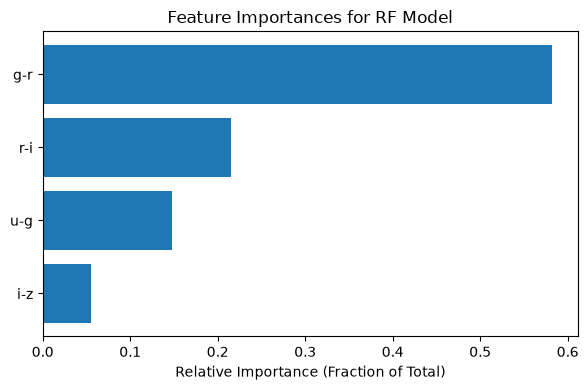

In [5]:
# Plot feature importance for Random Forest
import matplotlib.pyplot as plt
importances = rf_model.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 4))
plt.barh(np.array(feature_names)[order][::-1], importances[order][::-1])
plt.xlabel('Relative Importance (Fraction of Total)')
plt.title("Feature Importances for RF Model")
plt.tight_layout()
plt.show()

In [6]:
# Binned error analysis by redshift for both models
z_bins = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]

utils.binned_metrics(z_pred_val_rf, y_val, z_bins, label="RF Binned by Redshift")
utils.binned_metrics(z_pred_val_gb, y_val, z_bins, label="GB Binned by Redshift")

---- RF Binned by Redshift ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0213534238519155       0.0145615968418879       0.0483059929107246       
0.05-0.08   20352     0.0079713074901367       0.0128748449872944       0.0099744496855346       
0.08-0.10   14466     0.0003454451203817       0.0148397923097181       0.0064288676897553       
0.10-0.15   30557     -0.0064484240927274      0.0161761325724090       0.0238243283044802       
0.15-0.20   15183     -0.0074339167302792      0.0145363522511189       0.0366857669762234       
0.20-0.30   6096      -0.0098841310748177      0.0152379636087126       0.0400262467191601       


---- GB Binned by Redshift ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0214013120085728       0.0145418004919510       0.0482235594757234       
0.05-0.08   20352     0.0078434234492083       0.013

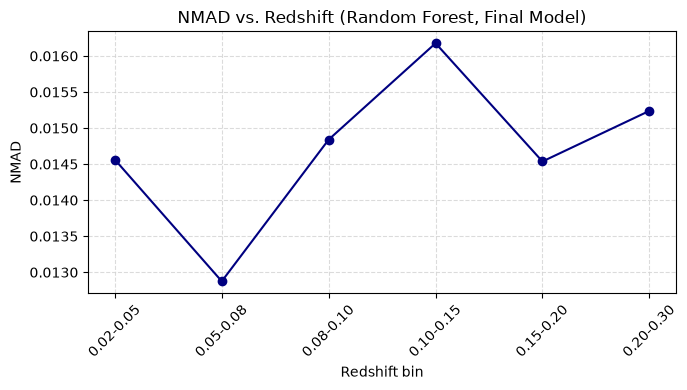

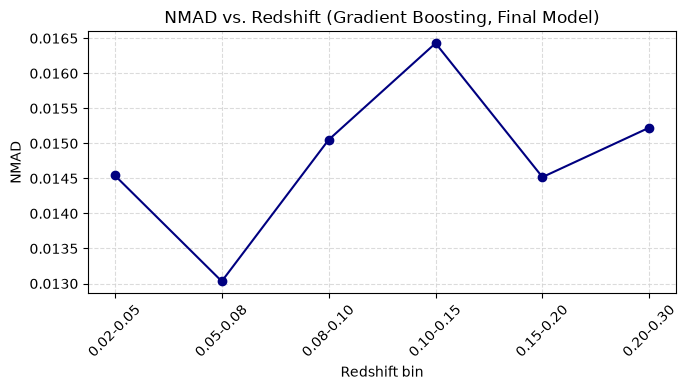

In [7]:
# Plot NMAD vs. Redshift for both models
utils.plot_nmad_vs_bin(z_pred_val_rf, y_val, z_bins, 'NMAD vs. Redshift (Random Forest, Final Model)')
utils.plot_nmad_vs_bin(z_pred_val_gb, y_val, z_bins, 'NMAD vs. Redshift (Gradient Boosting, Final Model)')

In [8]:
# Checking for degenerate regions in X_val
degenerate_mask = (
    (X_val['g-r'] > 0.4) & (X_val['g-r'] < 0.75) &
    (X_val['r-i'] > 0.15) & (X_val['r-i'] < 0.35)
)

# Use the mask to compare model performance in the degenerate region vs. the rest of the sample
for name, preds in [('RF', z_pred_val_rf), ('GB', z_pred_val_gb)]:
    zt_deg, zp_deg = y_val[degenerate_mask], preds[degenerate_mask]
    zt_rest, zp_rest = y_val[~degenerate_mask], preds[~degenerate_mask]

    print( "-" * 4, f"{name} Degenerate Region Check", "-" * 4)
    print(f"Degenerate region (N={degenerate_mask.sum()}):")
    print(f"  Outlier Fraction: {utils.outlier_fraction(zp_deg, zt_deg):.16f}")
    print(f"  NMAD:             {utils.nmad(zp_deg, zt_deg):.16f}")
    print(f"Rest of sample (N={(~degenerate_mask).sum()}):")
    print(f"  Outlier Fraction: {utils.outlier_fraction(zp_rest, zt_rest):.16f}")
    print(f"  NMAD:             {utils.nmad(zp_rest, zt_rest):.16f}")
    print("\n")

---- RF Degenerate Region Check ----
Degenerate region (N=12000):
  Outlier Fraction: 0.0380833333333333
  NMAD:             0.0202506161593711
Rest of sample (N=87063):
  Outlier Fraction: 0.0229259272021410
  NMAD:             0.0157199871062516


---- GB Degenerate Region Check ----
Degenerate region (N=12000):
  Outlier Fraction: 0.0365833333333333
  NMAD:             0.0207009459043572
Rest of sample (N=87063):
  Outlier Fraction: 0.0232590193308294
  NMAD:             0.0158381349173999


